### 1.数据准备和导入

In [1]:
import torch
import torchvision
import torchvision.transforms.v2 as v2
from torch.utils.data import DataLoader as DataLoader
import torch.nn as nn
import torch.optim as optim

In [2]:
transform = v2.Compose([v2.ToImage(),v2.ToDtype(torch.float32, scale = True)])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train = True,
    transform = transform,
    download = True
)

In [3]:
batch_size = 64
loaded_dataset = DataLoader(
    dataset= dataset,
    batch_size=batch_size,
    shuffle = True
)

In [4]:
print(f"dataset size: {len(dataset)}")
print(f"number of batch: {len(loaded_dataset)}")

dataset size: 60000
number of batch: 938


### 2. 网络编写

In [5]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.res_block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(in_channels=256,out_channels=256,kernel_size=3,padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=256,out_channels=256,kernel_size=1,padding = 0)
        )
        self.down_sample_1 = nn.Conv2d(in_channels=1,out_channels=256,kernel_size=4,padding=1,stride=2)
        self.down_sample_2 = nn.Conv2d(in_channels=256,out_channels=256,kernel_size=4,padding=1,stride=2)
        self.up_sample_1 = nn.ConvTranspose2d(in_channels=256,out_channels=256,kernel_size=4,padding=1,stride=2)
        self.up_sample_2 = nn.ConvTranspose2d(in_channels=256,out_channels=1,kernel_size=4,padding=1,stride=2)
        self.down_projection = nn.Conv2d(in_channels=256,out_channels=64,kernel_size=1,padding=0)
        self.up_projection = nn.Conv2d(in_channels=64,out_channels=256,kernel_size=1,padding=0)
        self.codebook = nn.Embedding(512,64)

    def encode(self,x):
        x = self.down_sample_1(x)
        x = self.down_sample_2(x)
        x = x + self.res_block(x)
        z_e = x + self.res_block(x)
        return z_e # z_e is encoder output [B,C,H,W]
    
    def decode(self,z_q): # z_q is decoder input
        z_q = z_q + self.res_block(z_q)
        z_q = z_q + self.res_block(z_q)
        z_q = self.up_sample_1(z_q)
        x_recon = self.up_sample_2(z_q)
        return x_recon # x_recon is reconstructed x as final output
    
    def quantization(self,z_e):
        z_e_down_projected = self.down_projection(z_e) # [B,64,7,7]
        z_e_permuted = torch.permute(z_e_down_projected,(0,2,3,1)).contiguous() # [B,7,7,64]
        z_e_flattened = z_e_permuted.view(-1,64) # [B*H*W, 64]
        #find |z - e|2 and argmin
        a_2 = torch.sum(z_e_flattened ** 2, dim = 1, keepdim = True) # [N,1]
        b_2 = torch.sum(self.codebook.weight ** 2, dim = 1) # [512]
        distance = a_2 + b_2 - 2 * torch.matmul(z_e_flattened, self.codebook.weight.t()) # .t() is transpose
        encoding_index = torch.argmin(distance, dim = -1) # dim indicates sum on which dimension

        z_q_flatten = self.codebook(encoding_index)

        z_q = z_q_flatten.view(z_e.shape[0],z_e.shape[2],z_e.shape[3],64) # [B,7,7,64]
        z_q_down_projected = torch.permute(z_q,(0,3,1,2)).contiguous() # [B,64,7,7]

        z_q = z_e_down_projected + (z_q_down_projected - z_e_down_projected).detach() # STE,forward process compute z_e + (z_q - z_e) = z_q, backward propagation compute z_e
        z_q = self.up_projection(z_q)
        return z_q, z_e_down_projected, z_q_down_projected
    
    def forward(self,x):
        z_e = self.encode(x)
        z_q, z_e_down_projected, z_q_down_projected = self.quantization(z_e)
        x_recon = self.decode(z_q)
        return x_recon, z_e_down_projected, z_q_down_projected

        
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Model().to(device)


### 3.训练循环

In [6]:
optimizer = optim.Adam(params=model.parameters(),lr = 2e-4)
loss_fn = nn.MSELoss()
beta = 0.25

def train(dataloader,loss_fn,model,optimizer,beta):
    train_loss = 0
    size = len(dataloader.dataset)
    for Batch, (X,_) in enumerate(dataloader):
        x_recon, z_e_down_projected, z_q_down_projected = model(X)
        # three losses
        recon_loss = loss_fn(X,x_recon)
        codebook_loss = loss_fn(z_q_down_projected,z_e_down_projected.detach())
        commitment_loss = loss_fn(z_q_down_projected.detach(),z_e_down_projected)

        loss = recon_loss + codebook_loss + beta * commitment_loss
        # back propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        if Batch % 100 == 0:
            loss, current = loss.item(), Batch * len(X)
            print()
            print(f"[{current:>5d}/{size:>5d}]")
            print(f"reconstruction loss: {recon_loss:>7f}")
            print(f"codebook loss: {codebook_loss:>7f}")
            print(f"commitment loss: {commitment_loss:>7f}")



In [ ]:
epoch = 20 
for i in range(epoch):
    print(f"epoch = {i+1}")
    train(loaded_dataset,loss_fn,model,optimizer,beta)

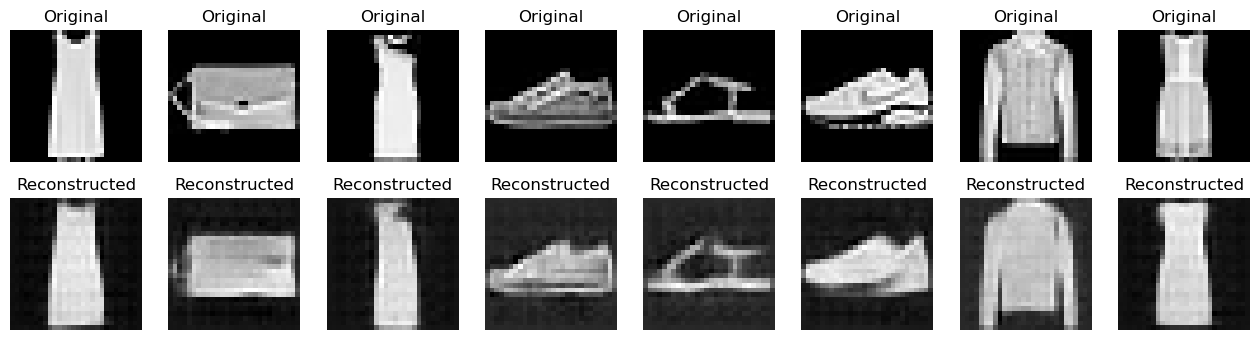

In [10]:
import matplotlib.pyplot as plt

state_dict = torch.load("models/vq_vae_epoch_21.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

images, _ = next(iter(loaded_dataset))

with torch.no_grad():

    images_device = images.to(device)
    
    outputs = model(images_device)
    reconstructed = outputs[0]  # obtain x_recon

images = images.squeeze().numpy()
reconstructed = reconstructed.cpu().view(-1, 28, 28).numpy()

n = 8
plt.figure(figsize=(16, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()